[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Model.ipynb)

# Librerie

In [1]:
!pip install obspy
!git clone https://github.com/Mpinaz/Thesis.git

fatal: destination path 'Thesis' already exists and is not an empty directory.


In [2]:
from obspy import read, Stream, UTCDateTime
from scipy.signal import stft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pickle as pk
import copy
from collections import defaultdict
import pandas as pd

rng = np.random.default_rng(42)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparing Dataset

In [4]:
catalog = pd.read_csv(
    '/content/Thesis/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
print(f"Time range: {catalog['time'].min()} to {catalog['time'].max()}")
print(f"Magnitude range: {catalog['mag'].min():.1f} – {catalog['mag'].max():.1f}")
catalog.head()

Loaded 11209 events
Time range: 2015-08-03 14:56:47.810000+00:00 to 2016-07-04 21:46:56.760000+00:00
Magnitude range: 0.0 – 3.1


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


In [5]:
# 90000 Registrations Pre Eruption
with open("/content/drive/MyDrive/Datasets/Pre_Events.pkl", "rb") as f:
    pre = pk.load(f)

# 4649 Registrations Post Eruption
with open("/content/drive/MyDrive/Datasets/Post_Events.pkl", "rb") as f:
    post = pk.load(f)
POST_set = {E for St, E, Reg in post}

In [6]:
per_evento = defaultdict(list)
for St, E, Reg in pre:
    per_evento[E].append((St, E, Reg))

eventi = list(per_evento.keys())

rng.shuffle(eventi)

Data = []
eventi_usati = []
for E in eventi:
    if len(Data) >= 4640:
        break
    Data.extend(per_evento[E])
    eventi_usati.append(E)

print(f"Registrazioni in Data: {len(Data)}")
print(f"Eventi usati:          {len(eventi_usati)}")

Events = Data + post
Events = [(St, E, D) for (St, E, D) in Events if all(tr.stats.npts >= 1000 for tr in D)]

Registrazioni in Data: 4648
Eventi usati:          425


In [9]:
X = np.arange(len(Events))
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])

groups_ev = np.array([E for (St, E, D) in Events])

def split_per_gruppo(groups):
    Train_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr, tmp = next(Train_Test_Shuffle.split(X, y, groups))

    Val_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    v, te = next(Val_Test_Shuffle.split(X[tmp], y[tmp], groups[tmp]))
    val, test = tmp[v], tmp[te]
    return tr, val, test

train_idx, val_idx, test_idx = split_per_gruppo(groups_ev)

# recupero dati
train = [Events[i] for i in train_idx]
val   = [Events[i] for i in val_idx]
test  = [Events[i] for i in test_idx]

In [10]:
for nome, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    lab = y[idx]
    print(f"{nome}: Eventi Post = {lab.sum()}, Eventi Pre = {len(lab)-lab.sum()}, Proporzione eventi post = {lab.mean():.3f}")

train: Eventi Post = 3697, Eventi Pre = 3772, Proporzione eventi post = 0.495
val: Eventi Post = 480, Eventi Pre = 443, Proporzione eventi post = 0.520
test: Eventi Post = 472, Eventi Pre = 433, Proporzione eventi post = 0.522


# CNN1D

In [11]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [12]:
train_ds_W = WaveDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_W   = WaveDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_W  = WaveDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Wave = DataLoader(train_ds_W, batch_size=32, shuffle=True)
val_loader_Wave   = DataLoader(val_ds_W,   batch_size=32)
test_loader_Wave  = DataLoader(test_ds_W,  batch_size=32)

In [13]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.3
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),

            # nn.Dropout(self.p),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),

            # nn.Dropout(self.p),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.MaxPool1d(2),
            nn.ReLU(),

            # In caso prova anche un Flatten
            nn.AdaptiveAvgPool1d(1),   # riduce l'asse temporale a 1
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):            # x: (batch, in_channels, lunghezza)
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
OneD_model = CNN().to(device)

crit = nn.CrossEntropyLoss()
opt = optim.Adam(OneD_model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10)

In [15]:
history1D = {"train_loss": [],
           "val_loss": [],
           "train_acc": [],
           "val_acc": []}
best_val_acc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    OneD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Wave:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = OneD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    OneD_model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader_Wave:
            x, y = x.to(device), y.to(device)
            out = OneD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)

    val_loss = tot_loss / total
    val_acc  = correct / total

    # scheduler.step(val_loss)   # da attivare con lo scheduler

    history1D["train_loss"].append(train_loss)
    history1D["val_loss"].append(val_loss)
    history1D["train_acc"].append(train_acc)
    history1D["val_acc"].append(val_acc)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}: \ntrain_loss={train_loss:.4f} \ntrain_acc={train_acc:.4f} \nval_loss={val_loss:.4f} \nval_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_state = copy.deepcopy(OneD_model.state_dict())

OneD_model.load_state_dict(best_state)
print(f"Best val accuracy: {best_val_acc:.4f}")

Training:  25%|██▌       | 25/100 [00:58<02:38,  2.12s/it]


Epoch 25: 
train_loss=0.2869 
train_acc=0.8776 
val_loss=0.4552 
val_acc=0.791


Training:  50%|█████     | 50/100 [01:54<01:48,  2.17s/it]


Epoch 50: 
train_loss=0.1693 
train_acc=0.9298 
val_loss=0.5650 
val_acc=0.798


Training:  75%|███████▌  | 75/100 [02:56<01:03,  2.52s/it]


Epoch 75: 
train_loss=0.1001 
train_acc=0.9612 
val_loss=0.5697 
val_acc=0.828


Training: 100%|██████████| 100/100 [03:53<00:00,  2.34s/it]


Epoch 100: 
train_loss=0.0780 
train_acc=0.9713 
val_loss=0.6284 
val_acc=0.811
Best val accuracy: 0.8332


# CNN2D

In [16]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [17]:
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
train_ds_S = SpecDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_S   = SpecDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_S  = SpecDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Spec = DataLoader(train_ds_S, batch_size=32, shuffle=True)
val_loader_Spec   = DataLoader(val_ds_S,   batch_size=32)
test_loader_Spec  = DataLoader(test_ds_S,  batch_size=32)

In [18]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(64, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm2d(128),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            # nn.Dropout(self.p),

            nn.Conv2d(128, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            # nn.Dropout(self.p),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),   # riduce l'asse temporale a 1
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
TwoD_model = CNN2D().to(device)

crit = nn.CrossEntropyLoss(label_smoothing=0.1)
opt = optim.Adam(TwoD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [20]:
history2D = {"train_loss": [],
           "val_loss": [],
           "train_acc": [],
           "val_acc": []}
best_val_acc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    TwoD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Spec:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = TwoD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    TwoD_model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader_Spec:
            x, y = x.to(device), y.to(device)
            out = TwoD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)

    val_loss = tot_loss / total
    val_acc  = correct / total

    scheduler.step(val_loss)   # da attivare con lo scheduler

    history2D["train_loss"].append(train_loss)
    history2D["val_loss"].append(val_loss)
    history2D["train_acc"].append(train_acc)
    history2D["val_acc"].append(val_acc)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}: \ntrain_loss={train_loss:.4f} \ntrain_acc={train_acc:.4f} \nval_loss={val_loss:.4f} \nval_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      best_state = copy.deepcopy(TwoD_model.state_dict())

TwoD_model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Training:  25%|██▌       | 25/100 [06:46<20:28, 16.38s/it]


Epoch 25: 
train_loss=0.2576 
train_acc=0.9653 
val_loss=0.4434 
val_acc=0.867


Training:  50%|█████     | 50/100 [13:35<13:23, 16.08s/it]


Epoch 50: 
train_loss=0.2063 
train_acc=0.9963 
val_loss=0.4313 
val_acc=0.894


Training:  75%|███████▌  | 75/100 [20:33<07:05, 17.01s/it]


Epoch 75: 
train_loss=0.2019 
train_acc=0.9981 
val_loss=0.4104 
val_acc=0.902


Training: 100%|██████████| 100/100 [27:17<00:00, 16.38s/it]


Epoch 100: 
train_loss=0.2007 
train_acc=0.9988 
val_loss=0.4128 
val_acc=0.904

Best val accuracy: 0.9079


# Results Plots

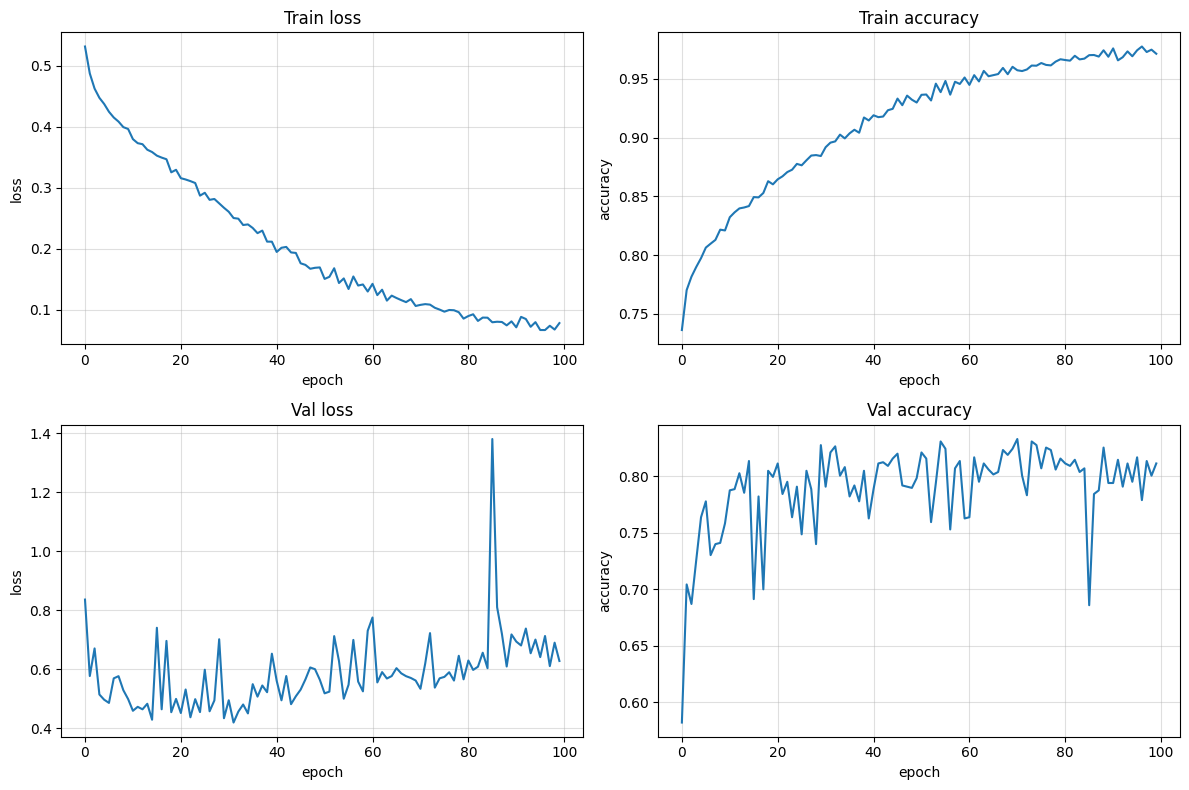

In [26]:
history, Using, model = history1D, "CNN1D", OneD_model

# history, Using, model= history2D, "CNN2D", TwoD_model

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(history["train_loss"])
ax[0, 0].set_title("Train loss")
ax[0, 0].set_xlabel("epoch"); ax[0, 0].set_ylabel("loss")
ax[0, 0].grid(alpha = 0.4)

ax[0, 1].plot(history["train_acc"])
ax[0, 1].set_title("Train accuracy")
ax[0, 1].set_xlabel("epoch"); ax[0, 1].set_ylabel("accuracy")
ax[0, 1].grid(alpha = 0.4)

ax[1, 0].plot(history["val_loss"])
ax[1, 0].set_title("Val loss")
ax[1, 0].set_xlabel("epoch"); ax[1, 0].set_ylabel("loss")
ax[1, 0].grid(alpha = 0.4)

ax[1, 1].plot(history["val_acc"])
ax[1, 1].set_title("Val accuracy")
ax[1, 1].set_xlabel("epoch"); ax[1, 1].set_ylabel("accuracy")
ax[1, 1].grid(alpha = 0.4)

fig.tight_layout()
# fig.savefig(f"{Using}: Train and Validation set during Training.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
def get_preds(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

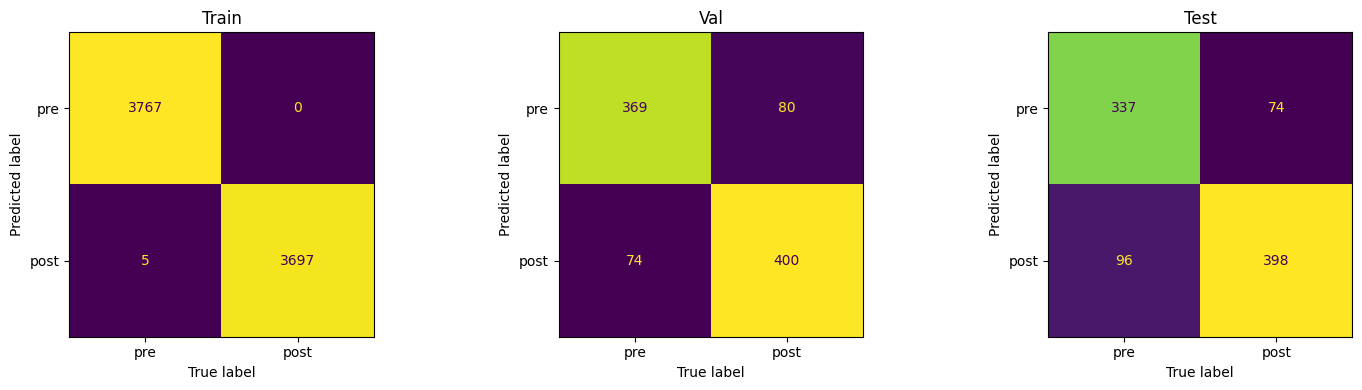

In [28]:
loaders = {"Train": train_loader_Spec, "Val": val_loader_Spec, "Test": test_loader_Spec} if Using == "CNN2D" else {"Train": train_loader_Wave, "Val": val_loader_Wave, "Test": test_loader_Wave}
labels  = ["pre", "post"]        # 0 = pre, 1 = post
model.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, loader) in zip(axes, loaders.items()):
    yt, yp = get_preds(model, loader)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm.T, display_labels=labels).plot(ax=ax, colorbar=False)
    ax.set_xlabel("True label")
    ax.set_ylabel("Predicted label")
    ax.set_title(name)

fig.tight_layout()
# fig.savefig(f"{Using}: Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
model.eval()
tst = test_loader_Wave if Using == "CNN1D" else test_loader_Spec
yt, yp = get_preds(model, tst)
test_acc = (yt == yp).mean()
print(f"Test accuracy for {Using}: {test_acc:.4f}")
# print(history)

Test accuracy for CNN1D: 0.8122


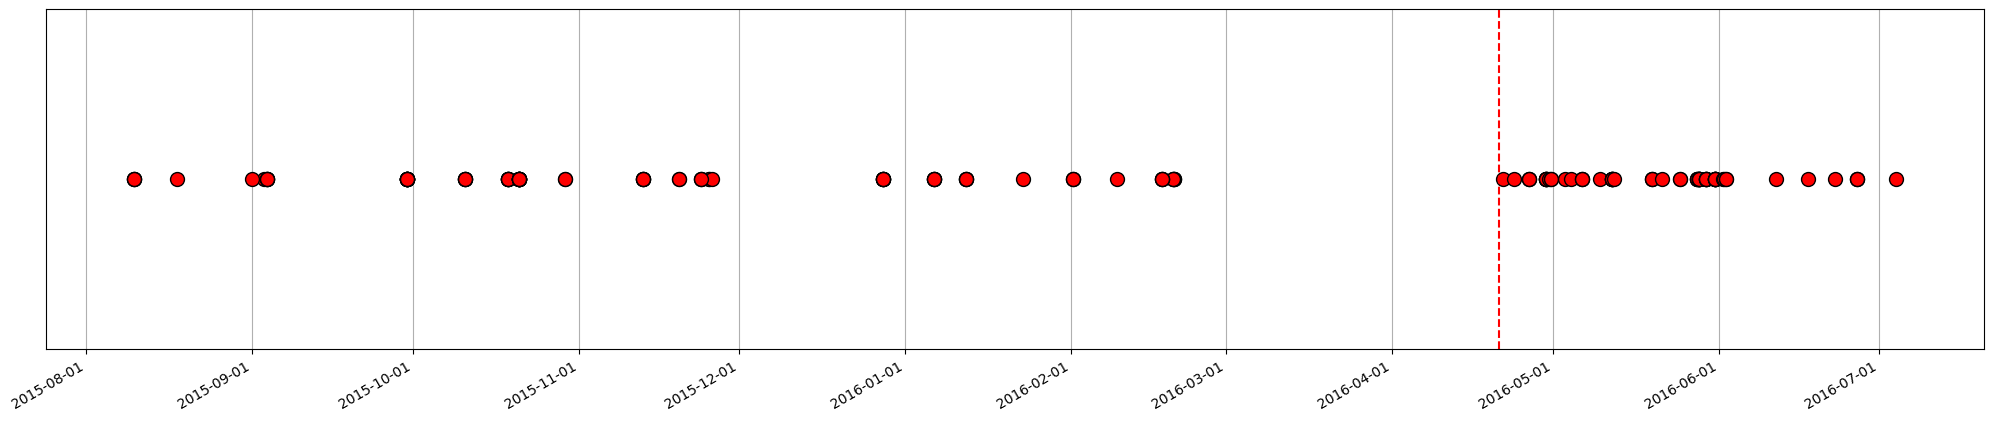

In [30]:
mis_idx = np.where(yt != yp)[0]

test_events = test_ds_W.events if Using == "CNN1D" else test_ds_S.events

Eventi_Errati = []
for i in mis_idx:
    Eventi_Errati.append(test_events[i][1])

tempi = catalog.loc[Eventi_Errati, "time"]

fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(tempi, [0]*len(tempi), "o",color = "red", ms = 10, markeredgecolor="black", markeredgewidth=1)
ax.yaxis.set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"),)
ax.axvline(pd.Timestamp("2016-04-21", tz="UTC") , color="red", linestyle="--")
ax.grid("on")
fig.autofmt_xdate()
plt.show()